In [0]:
# 1. )

from pyspark.sql import SparkSession


spark = SparkSession.builder.appName("Lab2_Task1").getOrCreate()


base_path = "/Volumes/big_data/default/pracownicy/"

print(f"Loading data from: {base_path}")

print("\n--- DataFrame Operations (Supported) ---")


df_movies = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(f"{base_path}movies.csv")


df_users = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(f"{base_path}users.csv")

print("Movies Schema:")
df_movies.printSchema()

print("Users Sample:")
df_users.show(5)



"""
# RDD Implementation Code:

# Load raw text files into RDDs
rdd_movies = spark.sparkContext.textFile(f"{base_path}movies.csv")
rdd_users = spark.sparkContext.textFile(f"{base_path}users.csv")

print("\n--- RDD Sample Output ---")
# Display first 5 lines of the raw text file
print(rdd_movies.take(5))
print(rdd_users.take(5))
"""

print("\n(RDD section skipped due to Serverless environment restrictions)")

Loading data from: /Volumes/big_data/default/pracownicy/

--- DataFrame Operations (Supported) ---
Movies Schema:
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

Users Sample:
+------+--------+--------+--------------------+
|userId|foreName| surName|               email|
+------+--------+--------+--------------------+
|     1|  Victor| Skinner|victor.skinner@mo...|
|     2|   Boris|  Howard|boris.howard@movi...|
|     3| Richard|   Avery|richard.avery@mov...|
|     4|   Simon|Metcalfe|simon.metcalfe@mo...|
|     5|  Robert|   Black|robert.black@movi...|
+------+--------+--------+--------------------+
only showing top 5 rows

(RDD section skipped due to Serverless environment restrictions)


2. ) DataFrame to wysokopoziomowa, zoptymalizowana tabela ze schematem danych (kolumny i typy), podczas gdy RDD to niskopoziomowa, surowa kolekcja obiektów bez struktury, wymagająca ręcznego zarządzania przetwarzaniem.

In [0]:
# 3.)
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

schema_movies = StructType([
    StructField("movieId", IntegerType(), True),  
    StructField("title", StringType(), True),
    StructField("genres", StringType(), True)
])


schema_users = StructType([
    StructField("userId", IntegerType(), True),
    StructField("foreName", StringType(), True),
    StructField("surName", StringType(), True),
    StructField("email", StringType(), True)
])


base_path = "/Volumes/big_data/default/pracownicy/"

print(f"Loading data with predefined schema from: {base_path}")


df_movies = spark.read.csv(f"{base_path}movies.csv", header=True, schema=schema_movies)
df_users = spark.read.csv(f"{base_path}users.csv", header=True, schema=schema_users)


print("--- Movies Schema ---")
df_movies.printSchema()
df_movies.show(3, truncate=False)

print("\n--- Users Schema ---")
df_users.printSchema()
df_users.show(3)

Loading data with predefined schema from: /Volumes/big_data/default/pracownicy/
--- Movies Schema ---
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

+-------+-----------------------+-------------------------------------------+
|movieId|title                  |genres                                     |
+-------+-----------------------+-------------------------------------------+
|1      |Toy Story (1995)       |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)         |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)|Comedy|Romance                             |
+-------+-----------------------+-------------------------------------------+
only showing top 3 rows

--- Users Schema ---
root
 |-- userId: integer (nullable = true)
 |-- foreName: string (nullable = true)
 |-- surName: string (nullable = true)
 |-- email: string (nullable = true)

+------+--------+-------

In [0]:
# 4.)

from pyspark.sql.functions import split, col, lit

base_path = "/Volumes/big_data/default/pracownicy/"
df_movies = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(f"{base_path}movies.csv")

df_movies_with_date = df_movies.withColumn("timestamp_str", lit("2023-11-15 14:30"))

print("--- Data with dummy timestamp ---")
df_movies_with_date.show(3, truncate=False)


df_parsed = df_movies_with_date \
    .withColumn("date_part", split(col("timestamp_str"), " ").getItem(0)) \
    .withColumn("time_part", split(col("timestamp_str"), " ").getItem(1)) \
    .withColumn("month", split(col("date_part"), "-").getItem(1).cast("int")) \
    .withColumn("day", split(col("date_part"), "-").getItem(2).cast("int")) \
    .withColumn("hour", split(col("time_part"), ":").getItem(0).cast("int")) \
    .drop("date_part", "time_part") 

print("--- Result with extracted columns ---")
df_parsed.select("title", "timestamp_str", "month", "day", "hour").show(5, truncate=False)

--- Data with dummy timestamp ---
+-------+-----------------------+-------------------------------------------+----------------+
|movieId|title                  |genres                                     |timestamp_str   |
+-------+-----------------------+-------------------------------------------+----------------+
|1      |Toy Story (1995)       |Adventure|Animation|Children|Comedy|Fantasy|2023-11-15 14:30|
|2      |Jumanji (1995)         |Adventure|Children|Fantasy                 |2023-11-15 14:30|
|3      |Grumpier Old Men (1995)|Comedy|Romance                             |2023-11-15 14:30|
+-------+-----------------------+-------------------------------------------+----------------+
only showing top 3 rows
--- Result with extracted columns ---
+----------------------------------+----------------+-----+---+----+
|title                             |timestamp_str   |month|day|hour|
+----------------------------------+----------------+-----+---+----+
|Toy Story (1995)               

In [0]:
# 5. )
from pyspark.sql.functions import split, explode, col, regexp_extract

base_path = "/Volumes/big_data/default/pracownicy/"
df_movies = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(f"{base_path}movies.csv")

from pyspark.sql.functions import split, explode, col, regexp_extract

# Używamy r"\|" zamiast "\|"
df_exploded = df_movies \
    .withColumn("year", regexp_extract(col("title"), r"\((\d{4})\)", 1)) \
    .withColumn("genre", explode(split(col("genres"), r"\|"))) \
    .select("movieId", "genre", "title", "year")



print("--- Movies with Exploded Genres ---")
df_exploded.show(10, truncate=False)

--- Movies with Exploded Genres ---
+-------+---------+-----------------------+----+
|movieId|genre    |title                  |year|
+-------+---------+-----------------------+----+
|1      |Adventure|Toy Story (1995)       |1995|
|1      |Animation|Toy Story (1995)       |1995|
|1      |Children |Toy Story (1995)       |1995|
|1      |Comedy   |Toy Story (1995)       |1995|
|1      |Fantasy  |Toy Story (1995)       |1995|
|2      |Adventure|Jumanji (1995)         |1995|
|2      |Children |Jumanji (1995)         |1995|
|2      |Fantasy  |Jumanji (1995)         |1995|
|3      |Comedy   |Grumpier Old Men (1995)|1995|
|3      |Romance  |Grumpier Old Men (1995)|1995|
+-------+---------+-----------------------+----+
only showing top 10 rows


In [0]:
# 6. )
base_path = "/Volumes/big_data/default/pracownicy/"

print("--- Ładowanie pliku ratings ---")

# 1. Wczytanie danych do DataFrame
df_ratings = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(f"{base_path}ratings.csv")

# 2. Wyświetlenie schematu (struktury kolumn i typów)
print("Schemat danych:")
df_ratings.printSchema()

# 3. Wyświetlenie pierwszych 5 wierszy (tabela z danymi)
print("Przykładowe dane:")
df_ratings.show(5)

--- Ładowanie pliku ratings ---
Schemat danych:
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

Przykładowe dane:
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
+------+-------+------+---------+
only showing top 5 rows


In [0]:
# 7. )

from pyspark.sql.functions import col, from_unixtime, year, month, dayofmonth


df_ratings = df_ratings.withColumn("datetime", from_unixtime(col("timestamp"))) \
                       .withColumn("year", year(col("datetime"))) \
                       .withColumn("month", month(col("datetime"))) \
                       .withColumn("day", dayofmonth(col("datetime")))

print("--- Ratings with Dates ---")
df_ratings.show(5)

--- Ratings with Dates ---
+------+-------+------+---------+-------------------+----+-----+---+
|userId|movieId|rating|timestamp|           datetime|year|month|day|
+------+-------+------+---------+-------------------+----+-----+---+
|     1|      1|   4.0|964982703|2000-07-30 18:45:03|2000|    7| 30|
|     1|      3|   4.0|964981247|2000-07-30 18:20:47|2000|    7| 30|
|     1|      6|   4.0|964982224|2000-07-30 18:37:04|2000|    7| 30|
|     1|     47|   5.0|964983815|2000-07-30 19:03:35|2000|    7| 30|
|     1|     50|   5.0|964982931|2000-07-30 18:48:51|2000|    7| 30|
+------+-------+------+---------+-------------------+----+-----+---+
only showing top 5 rows


In [0]:
# 8. )

ratings_per_year = df_ratings.groupBy("year") \
                             .count() \
                             .orderBy("year")

print("--- Number of ratings per year ---")
ratings_per_year.show()


--- Number of ratings per year ---
+----+-----+
|year|count|
+----+-----+
|1996| 6040|
|1997| 1916|
|1998|  507|
|1999| 2439|
|2000|10061|
|2001| 3922|
|2002| 3478|
|2003| 4014|
|2004| 3279|
|2005| 5813|
|2006| 4059|
|2007| 7114|
|2008| 4351|
|2009| 4158|
|2010| 2301|
|2011| 1690|
|2012| 4656|
|2013| 1664|
|2014| 1439|
|2015| 6616|
+----+-----+
only showing top 20 rows


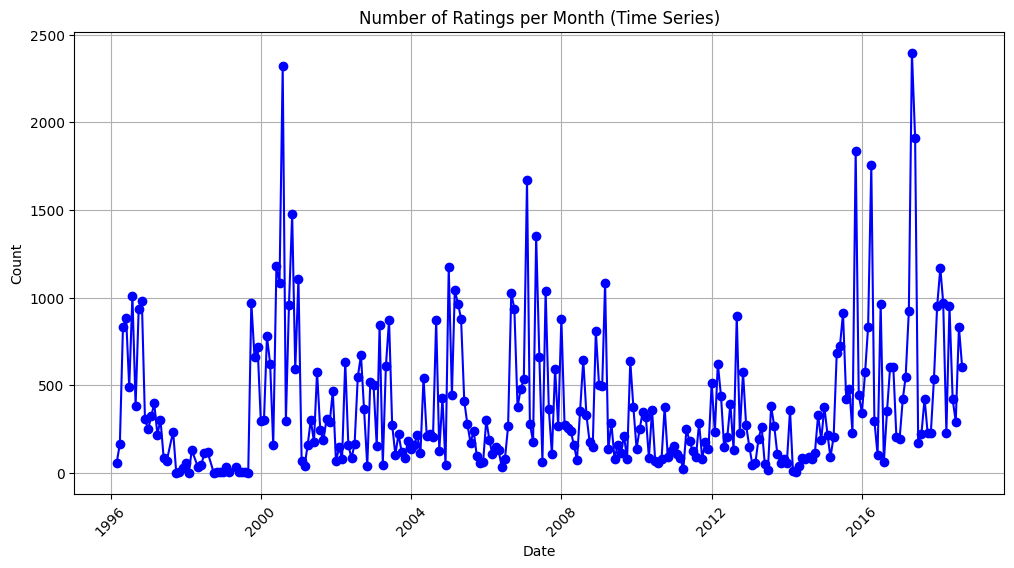

In [0]:
# 9. )
import matplotlib.pyplot as plt
import pandas as pd

ratings_per_month = df_ratings.groupBy("year", "month") \
                              .count() \
                              .orderBy("year", "month")

pdf = ratings_per_month.toPandas()


pdf["date"] = pd.to_datetime(pdf["year"].astype(str) + "-" + pdf["month"].astype(str) + "-01")

plt.figure(figsize=(12, 6)) 
plt.plot(pdf["date"], pdf["count"], marker='o', linestyle='-', color='b')

plt.title("Number of Ratings per Month (Time Series)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.xticks(rotation=45) 

plt.show()

In [0]:
# 10. )
base_path = "/Volumes/big_data/default/pracownicy/"

print(f"Loading tags from: {base_path}tags.csv")

df_tags = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(f"{base_path}tags.csv")

print("--- Schema Information ---")
df_tags.printSchema()

print("--- Data Preview ---")
df_tags.show(5)

Loading tags from: /Volumes/big_data/default/pracownicy/tags.csv
--- Schema Information ---
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: integer (nullable = true)

--- Data Preview ---
+------+-------+---------------+----------+
|userId|movieId|            tag| timestamp|
+------+-------+---------------+----------+
|     2|  60756|          funny|1445714994|
|     2|  60756|Highly quotable|1445714996|
|     2|  60756|   will ferrell|1445714992|
|     2|  89774|   Boxing story|1445715207|
|     2|  89774|            MMA|1445715200|
+------+-------+---------------+----------+
only showing top 5 rows


In [0]:
# 11. )

from pyspark.sql.functions import col, from_unixtime, year, month, dayofmonth

df_tags = df_tags.withColumn("datetime", from_unixtime(col("timestamp"))) \
                 .withColumn("year", year(col("datetime"))) \
                 .withColumn("month", month(col("datetime"))) \
                 .withColumn("day", dayofmonth(col("datetime")))

print("--- Tags with Date Columns ---")
df_tags.show(5, truncate=False)

--- Tags with Date Columns ---
+------+-------+---------------+----------+-------------------+----+-----+---+
|userId|movieId|tag            |timestamp |datetime           |year|month|day|
+------+-------+---------------+----------+-------------------+----+-----+---+
|2     |60756  |funny          |1445714994|2015-10-24 19:29:54|2015|10   |24 |
|2     |60756  |Highly quotable|1445714996|2015-10-24 19:29:56|2015|10   |24 |
|2     |60756  |will ferrell   |1445714992|2015-10-24 19:29:52|2015|10   |24 |
|2     |89774  |Boxing story   |1445715207|2015-10-24 19:33:27|2015|10   |24 |
|2     |89774  |MMA            |1445715200|2015-10-24 19:33:20|2015|10   |24 |
+------+-------+---------------+----------+-------------------+----+-----+---+
only showing top 5 rows


--- Tags Count per Month (Spark Output) ---
+----+-----+-----+
|year|month|count|
+----+-----+-----+
|2006|    1| 1462|
|2006|    2|   39|
|2006|    3|   13|
|2006|    4|    7|
|2006|    6|    1|
+----+-----+-----+
only showing top 5 rows


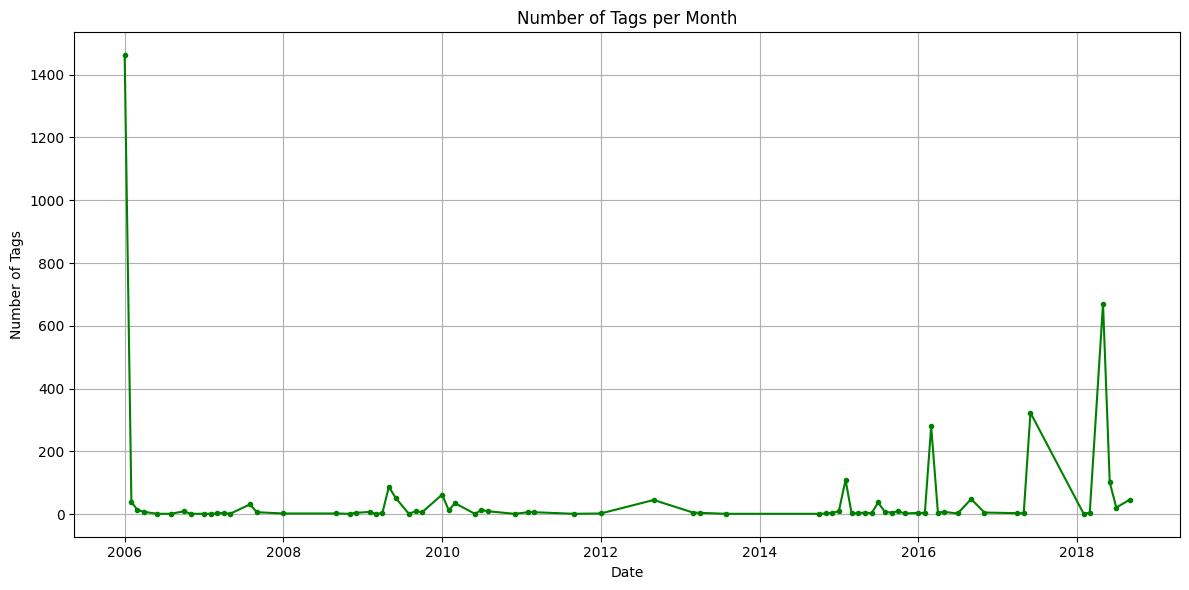

In [0]:
# 12. )

import matplotlib.pyplot as plt
import pandas as pd

tags_per_month = df_tags.groupBy("year", "month") \
                        .count() \
                        .orderBy("year", "month")

print("--- Tags Count per Month (Spark Output) ---")
tags_per_month.show(5)

pdf_tags = tags_per_month.toPandas()

pdf_tags["date"] = pd.to_datetime(
    pdf_tags["year"].astype(str) + "-" + pdf_tags["month"].astype(str) + "-01"
)

plt.figure(figsize=(12, 6))
plt.plot(pdf_tags["date"], pdf_tags["count"], color='green', marker='.', linestyle='-')

plt.title("Number of Tags per Month")
plt.xlabel("Date")
plt.ylabel("Number of Tags")
plt.grid(True)
plt.tight_layout()

plt.show()

In [0]:
# 13. )
base_path = "/Volumes/big_data/default/pracownicy/"


print(f"Loading movies from: {base_path}movies.csv")

df_movies = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(f"{base_path}movies.csv")

print("--- Movies Schema ---")
df_movies.printSchema()


print("--- Movies Preview ---")
df_movies.show(5, truncate=False)

Loading movies from: /Volumes/big_data/default/pracownicy/movies.csv
--- Movies Schema ---
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

--- Movies Preview ---
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
+-------+----------------------------------+---------

In [0]:
# 14. )

from pyspark.sql.functions import col, regexp_extract

base_path = "/Volumes/big_data/default/pracownicy/"

print(f"Loading ratings from: {base_path}ratings.csv")
df_ratings = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(f"{base_path}ratings.csv")


df_movies = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(f"{base_path}movies.csv")


df_movies_with_year = df_movies.withColumn(
    "production_year", 
    regexp_extract(col("title"), r"\((\d{4})\)", 1)
)

df_joined = df_movies_with_year.join(df_ratings, "movieId", "inner")

print("--- Joined Data Preview ---")
df_joined.show(5, truncate=False)

Loading ratings from: /Volumes/big_data/default/pracownicy/ratings.csv
--- Joined Data Preview ---
+-------+---------------------------+-------------------------------------------+---------------+------+------+---------+
|movieId|title                      |genres                                     |production_year|userId|rating|timestamp|
+-------+---------------------------+-------------------------------------------+---------------+------+------+---------+
|1      |Toy Story (1995)           |Adventure|Animation|Children|Comedy|Fantasy|1995           |1     |4.0   |964982703|
|3      |Grumpier Old Men (1995)    |Comedy|Romance                             |1995           |1     |4.0   |964981247|
|6      |Heat (1995)                |Action|Crime|Thriller                      |1995           |1     |4.0   |964982224|
|47     |Seven (a.k.a. Se7en) (1995)|Mystery|Thriller                           |1995           |1     |5.0   |964983815|
|50     |Usual Suspects, The (1995) |Crime|Myst

In [0]:
# 15. )
from pyspark.sql.functions import col, min, max, avg, count, desc

df_grouped = df_joined.groupBy("title").agg(
    min("rating").alias("min_rating"),
    avg("rating").alias("avg_rating"),
    max("rating").alias("max_rating"),
    count("rating").alias("rating_cnt")
)

df_result = df_grouped.orderBy(col("rating_cnt").desc())

print("--- Aggregated Movies Stats ---")
df_result.show(5, truncate=False)

--- Aggregated Movies Stats ---
+--------------------------------+----------+-----------------+----------+----------+
|title                           |min_rating|avg_rating       |max_rating|rating_cnt|
+--------------------------------+----------+-----------------+----------+----------+
|Forrest Gump (1994)             |0.5       |4.164133738601824|5.0       |329       |
|Shawshank Redemption, The (1994)|1.0       |4.429022082018927|5.0       |317       |
|Pulp Fiction (1994)             |0.5       |4.197068403908795|5.0       |307       |
|Silence of the Lambs, The (1991)|0.5       |4.161290322580645|5.0       |279       |
|Matrix, The (1999)              |0.5       |4.192446043165468|5.0       |278       |
+--------------------------------+----------+-----------------+----------+----------+
only showing top 5 rows


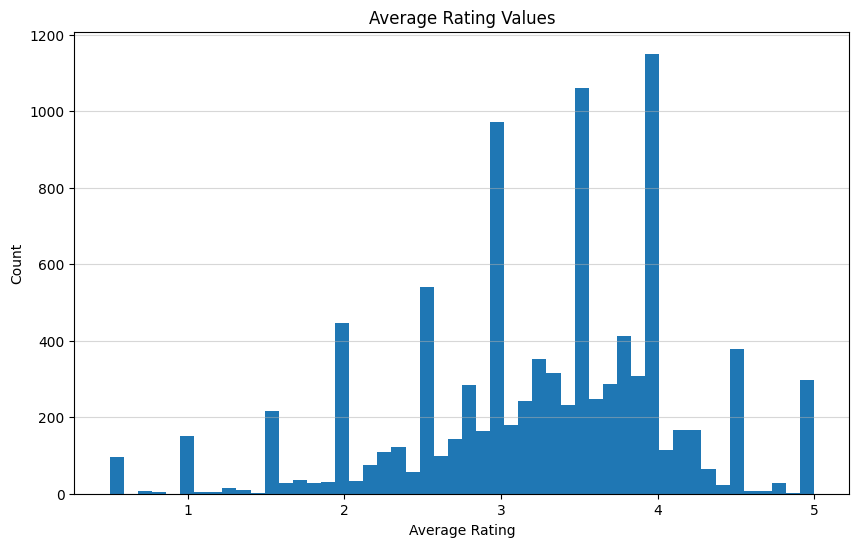

In [0]:
# 16. )
import matplotlib.pyplot as plt

avg_ratings_rows = df_result.select("avg_rating") \
    .where("rating_cnt >= 0") \
    .collect()

avg_ratings = [row["avg_rating"] for row in avg_ratings_rows]

plt.figure(figsize=(10, 6))

plt.hist(avg_ratings, bins=50, edgecolor='none') 

plt.title("Average Rating Values")  
plt.xlabel("Average Rating")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.5)

plt.show()

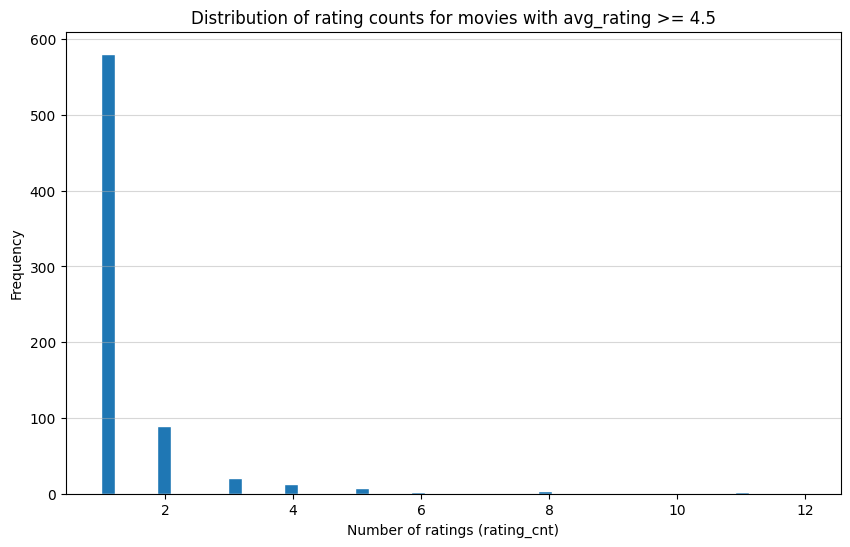

In [0]:
# 17. )

import matplotlib.pyplot as plt
from pyspark.sql.functions import col

rating_counts_rows = df_result \
    .where("avg_rating >= 4.5") \
    .select("rating_cnt") \
    .collect()

rating_counts_list = [float(row["rating_cnt"]) for row in rating_counts_rows]

plt.figure(figsize=(10, 6))

plt.hist(rating_counts_list, bins=50, edgecolor='white')

plt.title("Distribution of rating counts for movies with avg_rating >= 4.5")
plt.xlabel("Number of ratings (rating_cnt)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)

plt.show()

In [0]:
from pyspark.sql.functions import col, regexp_extract, from_unixtime, year, when, lit

df_movies_temp = df_movies.withColumn(
    "year_str", 
    regexp_extract(col("title"), r"\((\d{4})\)", 1)
)

df_movies_prep = df_movies_temp.withColumn(
    "year",
    when(col("year_str") == "", None)
    .otherwise(col("year_str"))
    .cast("int")
).drop("year_str") 

df_ratings_prep = df_ratings.withColumn(
    "datetime", 
    from_unixtime(col("timestamp"))
)

df_mr = df_movies_prep.alias("m").join(
    df_ratings_prep.alias("r"),
    col("m.movieId") == col("r.movieId")
)

df_mr = df_mr.withColumn(
    "release_to_rating_year",
    (year(col("datetime")) - col("year")).cast("double")
)

df_final = df_mr.drop(col("r.movieId"))

columns_to_show = [
    "movieId", "genres", "title", "year", 
    "userId", "rating", "datetime", "release_to_rating_year"
]

print("--- Final DataFrame with Time Difference ---")
df_final.select(columns_to_show).show(5, truncate=False)

--- Final DataFrame with Time Difference ---
+-------+-------------------------------------------+---------------------------+----+------+------+-------------------+----------------------+
|movieId|genres                                     |title                      |year|userId|rating|datetime           |release_to_rating_year|
+-------+-------------------------------------------+---------------------------+----+------+------+-------------------+----------------------+
|1      |Adventure|Animation|Children|Comedy|Fantasy|Toy Story (1995)           |1995|1     |4.0   |2000-07-30 18:45:03|5.0                   |
|3      |Comedy|Romance                             |Grumpier Old Men (1995)    |1995|1     |4.0   |2000-07-30 18:20:47|5.0                   |
|6      |Action|Crime|Thriller                      |Heat (1995)                |1995|1     |4.0   |2000-07-30 18:37:04|5.0                   |
|47     |Mystery|Thriller                           |Seven (a.k.a. Se7en) (1995)|1995|1    

In [0]:
# 19. ) Pobierz listę wartości i wyświetl histogram.
# W dokumencie z zdaniem jest "Nie działa…" więc chyba to zadanie pomijamy? 


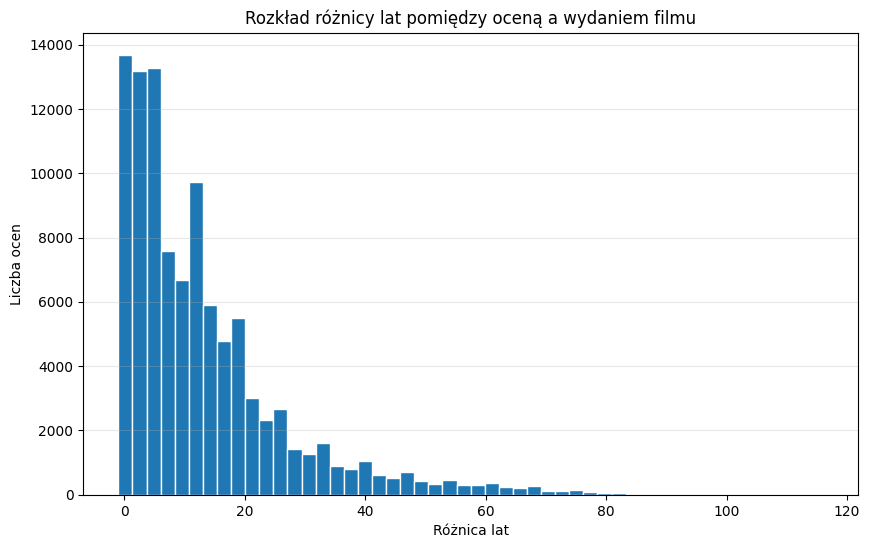

In [0]:
# 20. )

import matplotlib.pyplot as plt

data_rows = df_final.select("release_to_rating_year") \
    .filter("release_to_rating_year IS NOT NULL") \
    .collect()

years_diff = [row["release_to_rating_year"] for row in data_rows]

plt.figure(figsize=(10, 6))

plt.hist(years_diff, bins=50, edgecolor='white') 

plt.title("Rozkład różnicy lat pomiędzy oceną a wydaniem filmu")
plt.xlabel("Różnica lat")
plt.ylabel("Liczba ocen")
plt.grid(axis='y', alpha=0.3)

plt.show()

In [0]:
# 21. )

from pyspark.sql.functions import col

df_year_distribution = df_final.groupBy("release_to_rating_year") \
    .count() \
    .orderBy("release_to_rating_year")

print("--- Distribution of Time Differences ---")
df_year_distribution.show(20)
df_problematic = df_final.filter("release_to_rating_year = -1 OR release_to_rating_year IS NULL")

print("--- Problematic Records Preview ---")
df_problematic.select("title", "year", "rating", "datetime", "release_to_rating_year").show(20, truncate=False)

--- Distribution of Time Differences ---
+----------------------+-----+
|release_to_rating_year|count|
+----------------------+-----+
|                  NULL|   18|
|                  -1.0|    3|
|                   0.0| 3809|
|                   1.0| 9876|
|                   2.0| 7390|
|                   3.0| 5788|
|                   4.0| 4695|
|                   5.0| 4382|
|                   6.0| 4197|
|                   7.0| 3891|
|                   8.0| 3705|
|                   9.0| 3336|
|                  10.0| 3359|
|                  11.0| 3359|
|                  12.0| 3252|
|                  13.0| 3125|
|                  14.0| 3077|
|                  15.0| 2817|
|                  16.0| 2543|
|                  17.0| 2237|
+----------------------+-----+
only showing top 20 rows
--- Problematic Records Preview ---
+-------------------------------------------------------+----+------+-------------------+----------------------+
|title                                   

In [0]:
# 22. )

from pyspark.sql.functions import col, regexp_extract, when

regex_old = r"\((\d{4})\)"
regex_new = r"\((\d{4})\)\s*"

df_compare = df_movies.withColumn("year_old_str", regexp_extract(col("title"), regex_old, 1)) \
                      .withColumn("year_new_str", regexp_extract(col("title"), regex_new, 1))

df_compare = df_compare.withColumn("year_old", when(col("year_old_str") == "", None).otherwise(col("year_old_str"))) \
                       .withColumn("year_new", when(col("year_new_str") == "", None).otherwise(col("year_new_str")))

nulls_old = df_compare.filter("year_old IS NULL").count()
nulls_new = df_compare.filter("year_new IS NULL").count()

print(f"Liczba NULL (Stary Regex): {nulls_old}")
print(f"Liczba NULL (Nowy Regex):  {nulls_new}")
print(f"Zmniejszenie liczby NULL:  {nulls_old - nulls_new}")

df_fixed = df_compare.filter("year_old IS NULL AND year_new IS NOT NULL")
if df_fixed.count() > 0:
    print("--- Examples of rescued records ---")
    df_fixed.select("title", "year_new").show(5, truncate=False)
else:
    print("Zmiana regexu nie wpłynęła na liczbę dopasowań w tym zbiorze danych.")

Liczba NULL (Stary Regex): 13
Liczba NULL (Nowy Regex):  13
Zmniejszenie liczby NULL:  0
Zmiana regexu nie wpłynęła na liczbę dopasowań w tym zbiorze danych.


In [0]:
# 23. )
from pyspark.sql.functions import col, regexp_extract, when

regex_pattern = r"^(.*?)\s*\((\d{4})\)\s*$"

df_movies_cleaned = df_movies.withColumn("title_cleaned",
    when(
        regexp_extract(col("title"), regex_pattern, 1) == "", 
        col("title")
    )
    .otherwise(
        regexp_extract(col("title"), regex_pattern, 1)
    )
)

df_movies_cleaned = df_movies_cleaned.withColumn("year_extracted",
    regexp_extract(col("title"), regex_pattern, 2)
)

print("--- Cleaned Title Preview ---")s
df_movies_cleaned.select("title", "title_cleaned", "year_extracted").show(10, truncate=False)


--- Cleaned Title Preview ---
+----------------------------------+---------------------------+--------------+
|title                             |title_cleaned              |year_extracted|
+----------------------------------+---------------------------+--------------+
|Toy Story (1995)                  |Toy Story                  |1995          |
|Jumanji (1995)                    |Jumanji                    |1995          |
|Grumpier Old Men (1995)           |Grumpier Old Men           |1995          |
|Waiting to Exhale (1995)          |Waiting to Exhale          |1995          |
|Father of the Bride Part II (1995)|Father of the Bride Part II|1995          |
|Heat (1995)                       |Heat                       |1995          |
|Sabrina (1995)                    |Sabrina                    |1995          |
|Tom and Huck (1995)               |Tom and Huck               |1995          |
|Sudden Death (1995)               |Sudden Death               |1995          |
|GoldenEye

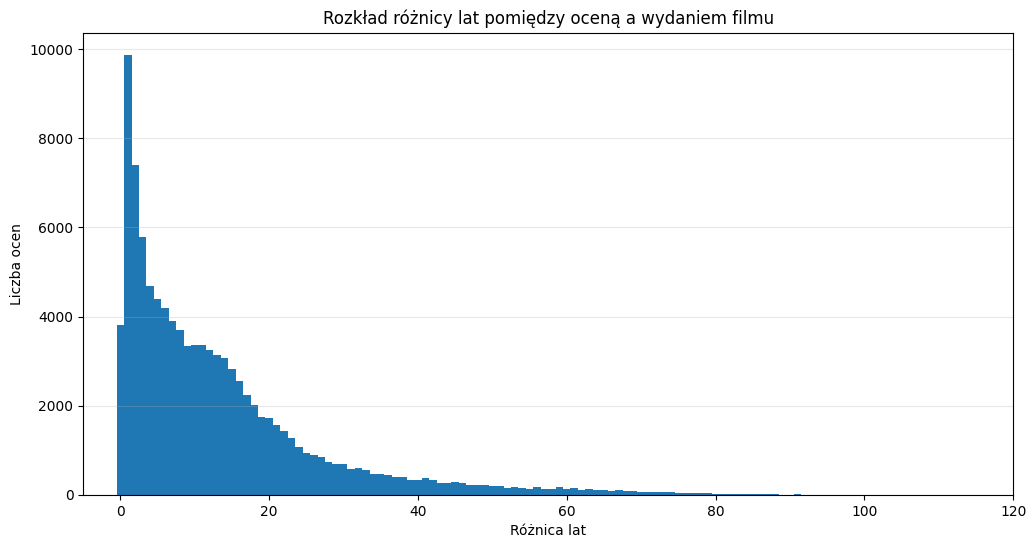

In [0]:
# 24. )

import matplotlib.pyplot as plt

df_plot_data = df_year_distribution \
    .filter("release_to_rating_year IS NOT NULL") \
    .orderBy("release_to_rating_year")

data_rows = df_plot_data.collect()

x_years = [row['release_to_rating_year'] for row in data_rows]
y_counts = [row['count'] for row in data_rows]

plt.figure(figsize=(12, 6))

plt.bar(x_years, y_counts, width=1.0, align='center')

plt.title("Rozkład różnicy lat pomiędzy oceną a wydaniem filmu")
plt.xlabel("Różnica lat") 
plt.ylabel("Liczba ocen") 

plt.xlim(-5, 120)

plt.grid(axis='y', alpha=0.3)
plt.show()

In [0]:
# 25. )

from pyspark.sql.functions import split, explode, col
df_movies_exploded = df_movies.withColumn(
    "genre", 
    explode(split(col("genres"), "\\|"))
)

df_movies_ratings_genres = df_movies_exploded.join(df_ratings, "movieId", "inner")

print("--- Movies Ratings by Genre Preview ---")
df_movies_ratings_genres.select("movieId", "title", "genre", "rating").show(10, truncate=False)

--- Movies Ratings by Genre Preview ---
+-------+---------------------------+--------+------+
|movieId|title                      |genre   |rating|
+-------+---------------------------+--------+------+
|1      |Toy Story (1995)           |Fantasy |4.0   |
|3      |Grumpier Old Men (1995)    |Romance |4.0   |
|6      |Heat (1995)                |Thriller|4.0   |
|47     |Seven (a.k.a. Se7en) (1995)|Thriller|5.0   |
|50     |Usual Suspects, The (1995) |Thriller|5.0   |
|70     |From Dusk Till Dawn (1996) |Thriller|3.0   |
|101    |Bottle Rocket (1996)       |Romance |5.0   |
|110    |Braveheart (1995)          |War     |4.0   |
|151    |Rob Roy (1995)             |War     |5.0   |
|157    |Canadian Bacon (1995)      |War     |5.0   |
+-------+---------------------------+--------+------+
only showing top 10 rows


In [0]:
# 26. )

from pyspark.sql.functions import col, split, explode, regexp_extract, from_unixtime, when

df_movies_processed = df_movies.withColumn(
    "year",
    when(regexp_extract(col("title"), r"\((\d{4})\)", 1) == "", None)
    .otherwise(regexp_extract(col("title"), r"\((\d{4})\)", 1).cast("int"))
).withColumn(
    "genre",
    explode(split(col("genres"), "\\|"))
)

df_ratings_processed = df_ratings.withColumn(
    "datetime",
    from_unixtime(col("timestamp"))
)

df_joined_genres = df_movies_processed.alias("m").join(
    df_ratings_processed.alias("r"),
    col("m.movieId") == col("r.movieId")
)

columns_to_show = [
    col("m.movieId"), 
    col("genre"), 
    col("title"), 
    col("year"), 
    col("userId"), 
    col("r.movieId"), 
    col("rating"), 
    col("datetime")
]

print("--- Movies Ratings by Genre ---")
df_joined_genres.select(columns_to_show).show(10, truncate=False)

--- Movies Ratings by Genre ---
+-------+--------+---------------------------+----+------+-------+------+-------------------+
|movieId|genre   |title                      |year|userId|movieId|rating|datetime           |
+-------+--------+---------------------------+----+------+-------+------+-------------------+
|1      |Fantasy |Toy Story (1995)           |1995|1     |1      |4.0   |2000-07-30 18:45:03|
|3      |Romance |Grumpier Old Men (1995)    |1995|1     |3      |4.0   |2000-07-30 18:20:47|
|6      |Thriller|Heat (1995)                |1995|1     |6      |4.0   |2000-07-30 18:37:04|
|47     |Thriller|Seven (a.k.a. Se7en) (1995)|1995|1     |47     |5.0   |2000-07-30 19:03:35|
|50     |Thriller|Usual Suspects, The (1995) |1995|1     |50     |5.0   |2000-07-30 18:48:51|
|70     |Thriller|From Dusk Till Dawn (1996) |1996|1     |70     |3.0   |2000-07-30 18:40:00|
|101    |Romance |Bottle Rocket (1996)       |1996|1     |101    |5.0   |2000-07-30 18:14:28|
|110    |War     |Braveheart

In [0]:
# 27. )

from pyspark.sql.functions import col, min, max, avg, count

df_genre_stats = df_joined_genres.groupBy("genre").agg(
    min("rating").alias("min_rating"),
    avg("rating").alias("avg_rating"),
    max("rating").alias("max_rating"),
    count("rating").alias("rating_cnt")
)

df_genre_stats = df_genre_stats.orderBy("genre")

print("--- Statistics by Genre ---")
df_genre_stats.show(25, truncate=False)

--- Statistics by Genre ---
+------------------+----------+------------------+----------+----------+
|genre             |min_rating|avg_rating        |max_rating|rating_cnt|
+------------------+----------+------------------+----------+----------+
|(no genres listed)|0.5       |3.4893617021276597|5.0       |47        |
|Action            |0.5       |3.447984331646809 |5.0       |30635     |
|Adventure         |0.5       |3.5086089151939075|5.0       |24161     |
|Animation         |0.5       |3.6299370349170004|5.0       |6988      |
|Children          |0.5       |3.412956125108601 |5.0       |9208      |
|Comedy            |0.5       |3.3847207640898267|5.0       |39053     |
|Crime             |0.5       |3.658293867274144 |5.0       |16681     |
|Documentary       |0.5       |3.797785069729286 |5.0       |1219      |
|Drama             |0.5       |3.6561844113718758|5.0       |41928     |
|Fantasy           |0.5       |3.4910005070136894|5.0       |11834     |
|Film-Noir         |0.5

In [0]:
# 28. )

from pyspark.sql.functions import col, desc

print("--- Top 3 Genres by Average Rating ---")
df_top_avg = df_genre_stats.orderBy(col("avg_rating").desc()).limit(3)
df_top_avg.show(truncate=False)

print("--- Top 3 Genres by Rating Count ---")
df_top_cnt = df_genre_stats.orderBy(col("rating_cnt").desc()).limit(3)
df_top_cnt.show(truncate=False)


--- Top 3 Genres by Average Rating ---
+-----------+----------+-----------------+----------+----------+
|genre      |min_rating|avg_rating       |max_rating|rating_cnt|
+-----------+----------+-----------------+----------+----------+
|Film-Noir  |0.5       |3.920114942528736|5.0       |870       |
|War        |0.5       |3.8082938876312  |5.0       |4859      |
|Documentary|0.5       |3.797785069729286|5.0       |1219      |
+-----------+----------+-----------------+----------+----------+

--- Top 3 Genres by Rating Count ---
+------+----------+------------------+----------+----------+
|genre |min_rating|avg_rating        |max_rating|rating_cnt|
+------+----------+------------------+----------+----------+
|Drama |0.5       |3.6561844113718758|5.0       |41928     |
|Comedy|0.5       |3.3847207640898267|5.0       |39053     |
|Action|0.5       |3.447984331646809 |5.0       |30635     |
+------+----------+------------------+----------+----------+



In [0]:
# 29. )

from pyspark.sql.functions import avg, col, lit

global_avg = df_ratings.select(avg("rating")).first()[0]

print(f"Global Average Rating (ratings.csv): {global_avg}")

df_above_average = df_genre_stats.filter(col("avg_rating") > lit(global_avg))

df_result = df_above_average.orderBy(col("avg_rating").desc())

print("--- Genres with Avg Rating > Global Average ---")
df_result.show(truncate=False)

Global Average Rating (ratings.csv): 3.501556983616962
--- Genres with Avg Rating > Global Average ---
+-----------+----------+------------------+----------+----------+
|genre      |min_rating|avg_rating        |max_rating|rating_cnt|
+-----------+----------+------------------+----------+----------+
|Film-Noir  |0.5       |3.920114942528736 |5.0       |870       |
|War        |0.5       |3.8082938876312   |5.0       |4859      |
|Documentary|0.5       |3.797785069729286 |5.0       |1219      |
|Crime      |0.5       |3.658293867274144 |5.0       |16681     |
|Drama      |0.5       |3.6561844113718758|5.0       |41928     |
|Mystery    |0.5       |3.632460255407871 |5.0       |7674      |
|Animation  |0.5       |3.6299370349170004|5.0       |6988      |
|IMAX       |0.5       |3.618335343787696 |5.0       |4145      |
|Western    |0.5       |3.583937823834197 |5.0       |1930      |
|Musical    |0.5       |3.5636781053649105|5.0       |4138      |
|Adventure  |0.5       |3.5086089151939

In [0]:
# 30. )

df_joined_genres.createOrReplaceTempView("movies_ratings")

df_ratings.createOrReplaceTempView("ratings")

query = """
    SELECT 
        genre, 
        AVG(rating) AS avg_rating, 
        COUNT(rating) AS rating_cnt,
        MIN(rating) AS min_rating,
        MAX(rating) AS max_rating
    FROM movies_ratings 
    GROUP BY genre 
    HAVING AVG(rating) > (SELECT AVG(rating) FROM ratings) 
    ORDER BY avg_rating DESC
"""

print("--- Wynik zapytania SQL (Gatunki powyżej średniej) ---")
df_cat_above_avg = spark.sql(query)

df_cat_above_avg.show(truncate=False)

--- Wynik zapytania SQL (Gatunki powyżej średniej) ---
+-----------+------------------+----------+----------+----------+
|genre      |avg_rating        |rating_cnt|min_rating|max_rating|
+-----------+------------------+----------+----------+----------+
|Film-Noir  |3.920114942528736 |870       |0.5       |5.0       |
|War        |3.8082938876312   |4859      |0.5       |5.0       |
|Documentary|3.797785069729286 |1219      |0.5       |5.0       |
|Crime      |3.658293867274144 |16681     |0.5       |5.0       |
|Drama      |3.6561844113718758|41928     |0.5       |5.0       |
|Mystery    |3.632460255407871 |7674      |0.5       |5.0       |
|Animation  |3.6299370349170004|6988      |0.5       |5.0       |
|IMAX       |3.618335343787696 |4145      |0.5       |5.0       |
|Western    |3.583937823834197 |1930      |0.5       |5.0       |
|Musical    |3.5636781053649105|4138      |0.5       |5.0       |
|Adventure  |3.5086089151939075|24161     |0.5       |5.0       |
|Romance    |3.506510

In [0]:
# 31. )

df_users = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(f"{base_path}users.csv")

df_tags = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(f"{base_path}tags.csv")

df_users.createOrReplaceTempView("users")
df_tags.createOrReplaceTempView("tags")


In [0]:
# 32. )

query = """
    SELECT 
        u.userId,
        u.foreName,
        u.surName,
        u.email,
        t.movieId,
        t.tag,
        t.timestamp
    FROM users u
    JOIN tags t ON u.userId = t.userId
"""

print("--- Joined Users and Tags Preview ---")
df_ut = spark.sql(query)
df_ut.show(10, truncate=False)

--- Joined Users and Tags Preview ---
+------+--------+--------+--------------------------+-------+-----------------+----------+
|userId|foreName|surName |email                     |movieId|tag              |timestamp |
+------+--------+--------+--------------------------+-------+-----------------+----------+
|2     |Boris   |Howard  |boris.howard@movies.com   |60756  |funny            |1445714994|
|2     |Boris   |Howard  |boris.howard@movies.com   |60756  |Highly quotable  |1445714996|
|2     |Boris   |Howard  |boris.howard@movies.com   |60756  |will ferrell     |1445714992|
|2     |Boris   |Howard  |boris.howard@movies.com   |89774  |Boxing story     |1445715207|
|2     |Boris   |Howard  |boris.howard@movies.com   |89774  |MMA              |1445715200|
|2     |Boris   |Howard  |boris.howard@movies.com   |89774  |Tom Hardy        |1445715205|
|2     |Boris   |Howard  |boris.howard@movies.com   |106782 |drugs            |1445715054|
|2     |Boris   |Howard  |boris.howard@movies.com   

In [0]:
# 33. )

from pyspark.sql.functions import collect_list, concat_ws

df_tags_grouped = df_ut.groupBy("email").agg(
    concat_ws(" ", collect_list("tag")).alias("tags")
)

print("--- User Tags Aggregated ---")
df_tags_grouped.show(truncate=30)

print("--- Printing Tag Lists ---")

tags_rows = df_tags_grouped.select("tags").collect()

for row in tags_rows:
    print(row["tags"])

--- User Tags Aggregated ---
+----------------------------+------------------------------+
|                       email|                          tags|
+----------------------------+------------------------------+
|    hannah.oliver@movies.com|assassin Jean Reno assassin...|
|      wanda.peake@movies.com|based on a book dark comedy...|
|  gordon.paterson@movies.com|                  way too long|
|caroline.hamilton@movies.com|post-college restaurant tra...|
|    jason.cornish@movies.com|Action assassin assassinati...|
| stephen.buckland@movies.com|passion psychological suspense|
|       faith.ross@movies.com|             funny high school|
|       sarah.bell@movies.com|fun off-beat comedy quirky ...|
|        amy.scott@movies.com|                    comic book|
|  melanie.abraham@movies.com|           jackie chan kung fu|
|     boris.howard@movies.com|funny Highly quotable will ...|
|     claire.jones@movies.com|time travel mystery twist e...|
|      carl.martin@movies.com|a clever ch

In [0]:
# 34. )

print(f"Loading users from: {base_path}users.csv")
df_users = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(f"{base_path}users.csv")

print(f"Loading ratings from: {base_path}ratings.csv")
df_ratings = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(f"{base_path}ratings.csv")

df_user_ratings = df_users.join(df_ratings, "userId", "inner")

print("--- Joined User Ratings Preview ---")
df_user_ratings.show(10)

Loading users from: /Volumes/big_data/default/pracownicy/users.csv
Loading ratings from: /Volumes/big_data/default/pracownicy/ratings.csv
--- Joined User Ratings Preview ---
+------+--------+-------+--------------------+-------+------+---------+
|userId|foreName|surName|               email|movieId|rating|timestamp|
+------+--------+-------+--------------------+-------+------+---------+
|     1|  Victor|Skinner|victor.skinner@mo...|      1|   4.0|964982703|
|     1|  Victor|Skinner|victor.skinner@mo...|      3|   4.0|964981247|
|     1|  Victor|Skinner|victor.skinner@mo...|      6|   4.0|964982224|
|     1|  Victor|Skinner|victor.skinner@mo...|     47|   5.0|964983815|
|     1|  Victor|Skinner|victor.skinner@mo...|     50|   5.0|964982931|
|     1|  Victor|Skinner|victor.skinner@mo...|     70|   3.0|964982400|
|     1|  Victor|Skinner|victor.skinner@mo...|    101|   5.0|964980868|
|     1|  Victor|Skinner|victor.skinner@mo...|    110|   4.0|964982176|
|     1|  Victor|Skinner|victor.sk

In [0]:
# 35. )

df_user_ratings = df_users.join(df_ratings, "userId", "inner")

print("--- User Ratings Joined Data ---")
df_user_ratings.show(5)

print("--- Schema of Joined Data ---")
df_user_ratings.printSchema()

--- User Ratings Joined Data ---
+------+--------+-------+--------------------+-------+------+---------+
|userId|foreName|surName|               email|movieId|rating|timestamp|
+------+--------+-------+--------------------+-------+------+---------+
|     1|  Victor|Skinner|victor.skinner@mo...|      1|   4.0|964982703|
|     1|  Victor|Skinner|victor.skinner@mo...|      3|   4.0|964981247|
|     1|  Victor|Skinner|victor.skinner@mo...|      6|   4.0|964982224|
|     1|  Victor|Skinner|victor.skinner@mo...|     47|   5.0|964983815|
|     1|  Victor|Skinner|victor.skinner@mo...|     50|   5.0|964982931|
+------+--------+-------+--------------------+-------+------+---------+
only showing top 5 rows
--- Schema of Joined Data ---
root
 |-- userId: integer (nullable = true)
 |-- foreName: string (nullable = true)
 |-- surName: string (nullable = true)
 |-- email: string (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nu

In [0]:
# 36. )

from pyspark.sql.functions import avg, count, col, desc

df_user_stats = df_user_ratings.groupBy("email").agg(
    avg("rating").alias("avg_rating"),
    count("rating").alias("count")
)

df_user_stats_sorted = df_user_stats.orderBy(col("avg_rating").desc())

print("--- User Ratings Statistics ---")
df_user_stats_sorted.show(5, truncate=False)

--- User Ratings Statistics ---
+--------------------------+------------------+-----+
|email                     |avg_rating        |count|
+--------------------------+------------------+-----+
|victoria.dyer@movies.com  |5.0               |20   |
|angela.morgan@movies.com  |4.869565217391305 |23   |
|natalie.wallace@movies.com|4.846153846153846 |26   |
|dorothy.lewis@movies.com  |4.8076923076923075|26   |
|liam.short@movies.com     |4.735294117647059 |34   |
+--------------------------+------------------+-----+
only showing top 5 rows


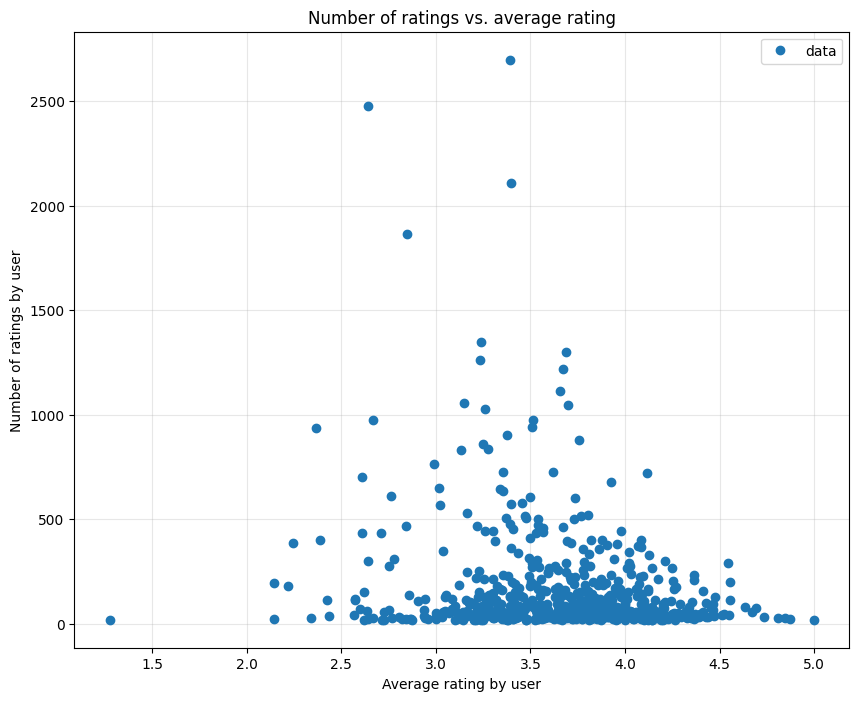

In [0]:
# 37. )

import matplotlib.pyplot as plt

rows = df_user_stats.select("avg_rating", "count").collect()

x_avg = [row["avg_rating"] for row in rows]
y_count = [row["count"] for row in rows]

plt.figure(figsize=(10, 8))

plt.plot(x_avg, y_count, "o", label="data") 

plt.title("Number of ratings vs. average rating")
plt.xlabel("Average rating by user")
plt.ylabel("Number of ratings by user")
plt.legend()            
plt.grid(True, alpha=0.3) 

plt.show()